<pre>Smart Ride Prediction
│
├── 1. Import Libraries
├── 2. Load Dataset
├── 3. Understand Dataset
├── 4. Data Cleaning
├── 5. Exploratory Data Analysis
├── 6. Feature Engineering
├── 7. Preprocessing
│
├── 8. Fare Prediction
│   ├── Linear Regression
│   ├── Random Forest
│   ├── Evaluation
│   └── Visualization
│
├── 9. Travel Time Prediction
│   ├── Linear Regression
│   ├── Random Forest
│   ├── Evaluation
│   └── Visualization
│
├── 10. Delay Risk Prediction
│   ├── Logistic Regression
│   ├── Random Forest
│   ├── Evaluation
│   └── Confusion Matrix
│
├── 11. Model Comparison
└── 12. Final Prediction System

<h2>Import Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

<H2>Load Dataset

In [16]:
df = pd.read_csv("./Dataset/fairfare_ride_demand_dataset.csv")
df.head()
print(f"Dataset of {} Rows Loaded Successfully!")

,City,Date,Day_of_Week,Latitude,Longitude,Ride_Distance_KM,Ride_Type,Weather,Event,Payment_Type,...,Fare_Acceptance,Cancellation_Rate,Time_of_Day,Demand_Score,Driver_Availability,Traffic_Delay,Cancellation_Probability,Driver_Trust_Score,Rider_Trust_Score,Leaderboard_Rank
0,Hyderabad,06-08-2024,1,17.353253,78.466332,6.76,Economy,Cloudy,Festival,UPI,...,0.857885,0.07,Afternoon,80,46,15,0.2,100.0,100,Below Average
1,Mumbai,26-09-2024,3,19.059839,72.858877,3.34,Premium,Stormy,Political Rally,Card,...,0.747193,0.07,Morning Peak,100,86,25,0.3,100.0,50,Below Average
2,Bangalore,27-07-2024,5,12.976855,77.625306,8.86,Luxury,Rainy,Festival,UPI,...,0.868523,0.08,Afternoon,100,32,15,0.3,100.0,100,Below Average
3,Mumbai,23-03-2025,6,19.056439,72.863508,15.95,Luxury,Cloudy,Concert,Cash,...,0.859991,0.07,Evening Peak,95,95,25,0.1,100.0,100,Below Average
4,Chennai,06-08-2024,1,13.110869,80.309381,19.50,Premium,Clear,NaN,Card,...,0.981357,0.05,Evening Peak,65,58,10,0.1,0.0,0,Below Average


<h2>Dataset information

In [17]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of rows: 10000
Number of columns: 29

Column Names:
['City', 'Date', 'Day_of_Week', 'Latitude', 'Longitude', 'Ride_Distance_KM', 'Ride_Type', 'Weather', 'Event', 'Payment_Type', 'Available_Drivers', 'Demand_Level', 'Surge_Multiplier', 'Final_Fare', 'Hour_of_Day', 'Is_Weekend', 'Driver_Performance_Score', 'Driver_XP', 'Ride_Priority', 'Fare_Acceptance', 'Cancellation_Rate', 'Time_of_Day', 'Demand_Score', 'Driver_Availability', 'Traffic_Delay', 'Cancellation_Probability', 'Driver_Trust_Score', 'Rider_Trust_Score', 'Leaderboard_Rank']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   City                      10000 non-null  object 
 1   Date                      10000 non-null  object 
 2   Day_of_Week               10000 non-null  int64  
 3   Latitude                  10000 non-null  flo

<h2>Check Missing Values & Remove Duplicate Records

In [22]:
print("Missing Values:")
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Missing Values:
City                           0
Date                           0
Day_of_Week                    0
Latitude                       0
Longitude                      0
Ride_Distance_KM               0
Ride_Type                      0
Weather                        0
Event                       2020
Payment_Type                   0
Available_Drivers              0
Demand_Level                   0
Surge_Multiplier               0
Final_Fare                     0
Hour_of_Day                    0
Is_Weekend                     0
Driver_Performance_Score       0
Driver_XP                      0
Ride_Priority                  0
Fare_Acceptance                0
Cancellation_Rate              0
Time_of_Day                    0
Demand_Score                   0
Driver_Availability            0
Traffic_Delay                  0
Cancellation_Probability       0
Driver_Trust_Score             0
Rider_Trust_Score              0
Leaderboard_Rank               0
dtype: int64
Duplicate rows

<h2>Numerical Columns

In [27]:
numeric_columns = df.select_dtypes(include=np.number).columns
print(numeric_columns.tolist())

['Day_of_Week', 'Latitude', 'Longitude', 'Ride_Distance_KM', 'Available_Drivers', 'Demand_Level', 'Surge_Multiplier', 'Final_Fare', 'Hour_of_Day', 'Is_Weekend', 'Driver_Performance_Score', 'Driver_XP', 'Ride_Priority', 'Fare_Acceptance', 'Cancellation_Rate', 'Demand_Score', 'Driver_Availability', 'Traffic_Delay', 'Cancellation_Probability', 'Driver_Trust_Score', 'Rider_Trust_Score']


<h2>Categorical Columns

In [29]:
categorical_columns = df.select_dtypes(include="object").columns
print(categorical_columns.tolist())

['City', 'Date', 'Ride_Type', 'Weather', 'Event', 'Payment_Type', 'Time_of_Day', 'Leaderboard_Rank']


<h2>Correlation Heatmap

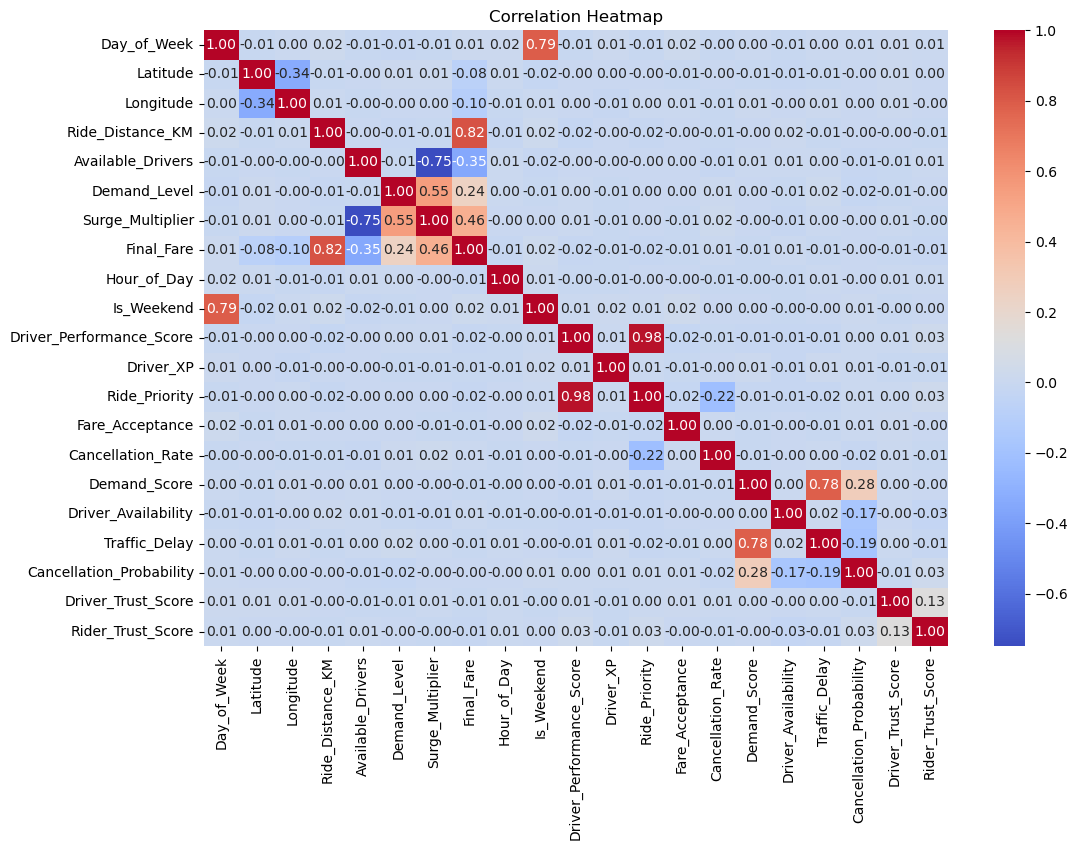

In [32]:
plt.figure(figsize=(12, 8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

<h2>Distribution of Numerical Features

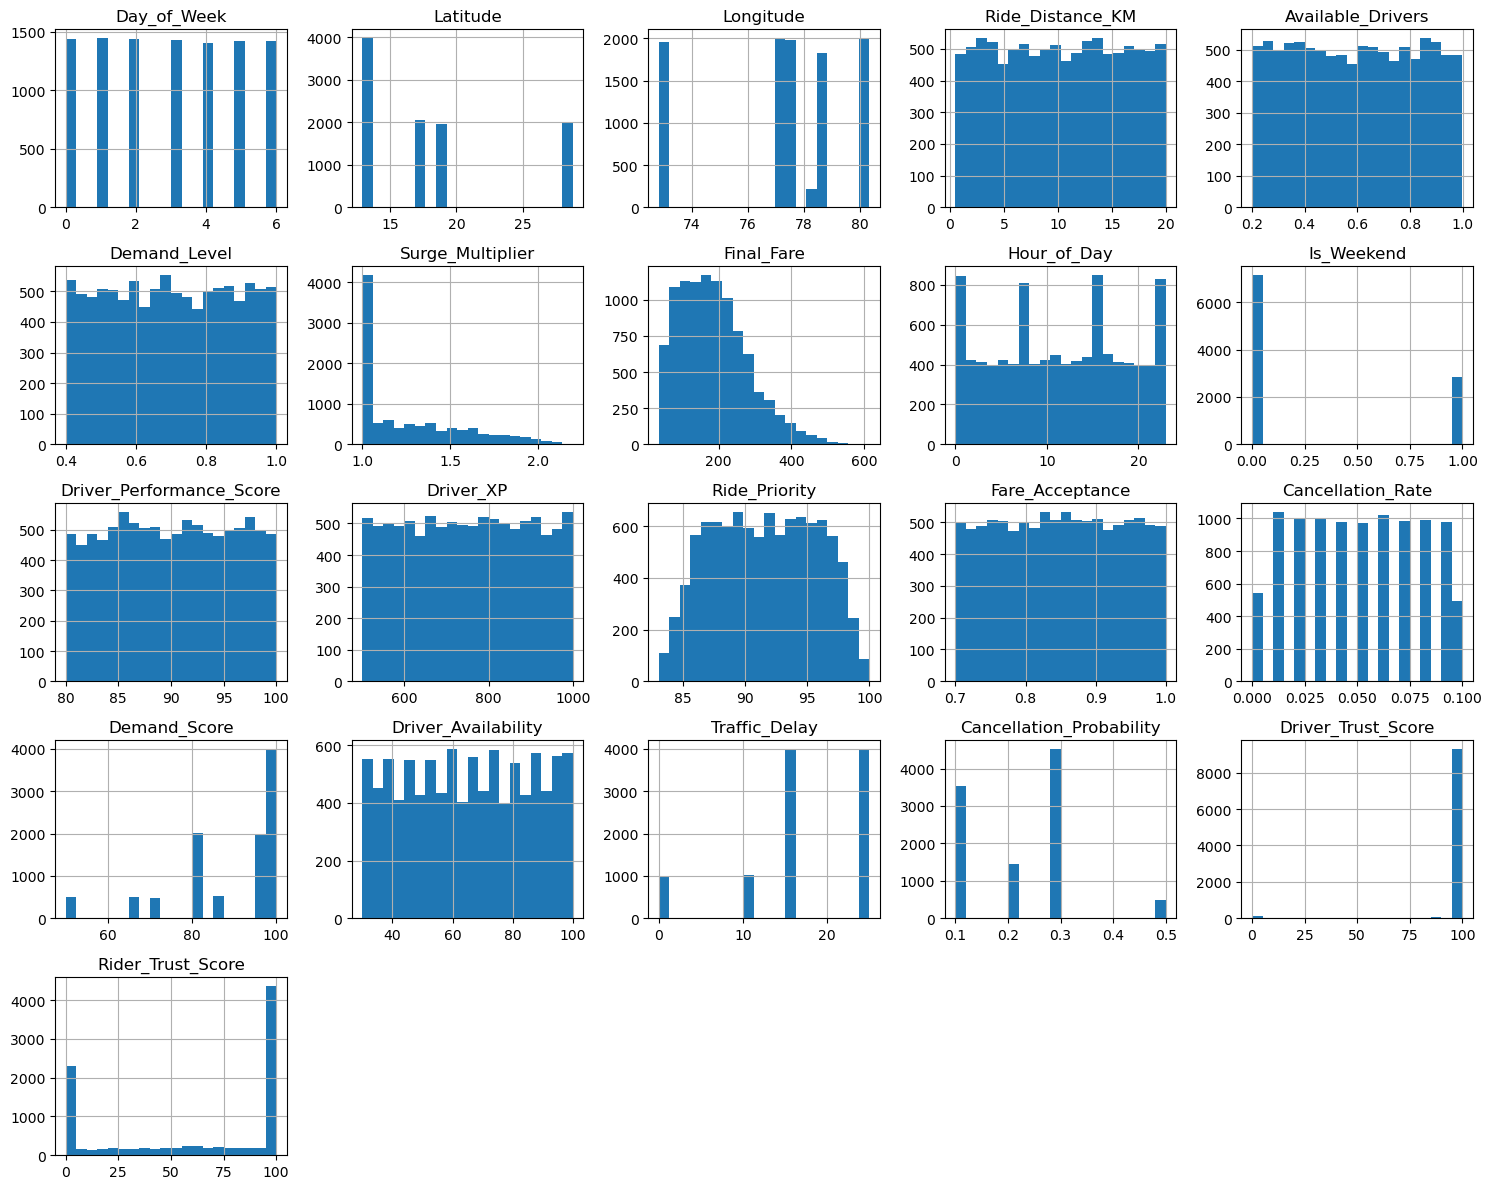

In [33]:
df.select_dtypes(include=np.number).hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

<h1>Fare Prediction

In [35]:
fare_features = [
    "distance",
    "demand",
    "surge",
    "traffic",
    "weather",
    "city",
    "driver_rating",
    "vehicle_type"
]

fare_target = "fare"
X_fare = df[fare_features]
y_fare = df[fare_target]

print("X shape:", X_fare.shape)
print("y shape:", y_fare.shape)

KeyError: "None of [Index(['distance', 'demand', 'surge', 'traffic', 'weather', 'city',\n       'driver_rating', 'vehicle_type'],\n      dtype='object')] are in the [columns]"